In [82]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import StandardScaler

In [83]:
os.getcwd()

'D:\\UDEMY PROJECTS\\Colorectal Cancer Prediction'

In [84]:
os.chdir(r"D:\UDEMY PROJECTS\Colorectal Cancer Prediction")

In [85]:
df = pd.read_csv("artifacts/raw/data.csv")
df.head()

,Patient_ID,Country,Age,Gender,Cancer_Stage,Tumor_Size_mm,Family_History,Smoking_History,Alcohol_Consumption,Obesity_BMI,...,Survival_5_years,Mortality,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K,Urban_or_Rural,Economic_Classification,Healthcare_Access,Insurance_Status,Survival_Prediction
0,1,UK,77,M,Localized,69,No,No,Yes,Overweight,...,Yes,No,54413,50,5,Urban,Developed,Moderate,Insured,Yes
1,2,UK,59,M,Localized,33,No,No,No,Overweight,...,Yes,No,76553,37,25,Urban,Developing,High,Uninsured,Yes
2,3,Japan,66,M,Regional,17,No,Yes,No,Normal,...,Yes,No,62805,54,27,Urban,Developed,Moderate,Uninsured,No
3,4,USA,83,M,Regional,14,No,No,No,Obese,...,Yes,No,89393,45,11,Urban,Developed,Moderate,Insured,Yes
4,5,France,66,M,Localized,34,No,Yes,No,Normal,...,Yes,No,66425,15,27,Urban,Developing,High,Insured,Yes


In [86]:
df.columns

Index(['Patient_ID', 'Country', 'Age', 'Gender', 'Cancer_Stage',
       'Tumor_Size_mm', 'Family_History', 'Smoking_History',
       'Alcohol_Consumption', 'Obesity_BMI', 'Diet_Risk', 'Physical_Activity',
       'Diabetes', 'Inflammatory_Bowel_Disease', 'Genetic_Mutation',
       'Screening_History', 'Early_Detection', 'Treatment_Type',
       'Survival_5_years', 'Mortality', 'Healthcare_Costs',
       'Incidence_Rate_per_100K', 'Mortality_Rate_per_100K', 'Urban_or_Rural',
       'Economic_Classification', 'Healthcare_Access', 'Insurance_Status',
       'Survival_Prediction'],
      dtype='str')

In [87]:
df.isnull().sum()

Patient_ID                    0
Country                       0
Age                           0
Gender                        0
Cancer_Stage                  0
Tumor_Size_mm                 0
Family_History                0
Smoking_History               0
Alcohol_Consumption           0
Obesity_BMI                   0
Diet_Risk                     0
Physical_Activity             0
Diabetes                      0
Inflammatory_Bowel_Disease    0
Genetic_Mutation              0
Screening_History             0
Early_Detection               0
Treatment_Type                0
Survival_5_years              0
Mortality                     0
Healthcare_Costs              0
Incidence_Rate_per_100K       0
Mortality_Rate_per_100K       0
Urban_or_Rural                0
Economic_Classification       0
Healthcare_Access             0
Insurance_Status              0
Survival_Prediction           0
dtype: int64

In [88]:
df.duplicated().sum()

np.int64(0)

In [89]:
df.shape

(167497, 28)

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167497 entries, 0 to 167496
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   Patient_ID                  167497 non-null  int64
 1   Country                     167497 non-null  str  
 2   Age                         167497 non-null  int64
 3   Gender                      167497 non-null  str  
 4   Cancer_Stage                167497 non-null  str  
 5   Tumor_Size_mm               167497 non-null  int64
 6   Family_History              167497 non-null  str  
 7   Smoking_History             167497 non-null  str  
 8   Alcohol_Consumption         167497 non-null  str  
 9   Obesity_BMI                 167497 non-null  str  
 10  Diet_Risk                   167497 non-null  str  
 11  Physical_Activity           167497 non-null  str  
 12  Diabetes                    167497 non-null  str  
 13  Inflammatory_Bowel_Disease  167497 non-null  str  
 14 

In [91]:
df.describe()

,Patient_ID,Age,Tumor_Size_mm,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K
count,167497.000000,167497.00000,167497.000000,167497.000000,167497.000000,167497.000000
mean,83749.000000,69.20078,42.005708,72452.168099,34.531562,17.023875
std,48352.363357,11.87247,21.672206,27402.779597,14.447970,7.208766
min,1.000000,30.00000,5.000000,25000.000000,10.000000,5.000000
25%,41875.000000,59.00000,23.000000,48760.000000,22.000000,11.000000
50%,83749.000000,69.00000,42.000000,72344.000000,35.000000,17.000000
75%,125623.000000,79.00000,61.000000,96227.000000,47.000000,23.000000
max,167497.000000,89.00000,79.000000,119999.000000,59.000000,29.000000


In [92]:
df.columns

Index(['Patient_ID', 'Country', 'Age', 'Gender', 'Cancer_Stage',
       'Tumor_Size_mm', 'Family_History', 'Smoking_History',
       'Alcohol_Consumption', 'Obesity_BMI', 'Diet_Risk', 'Physical_Activity',
       'Diabetes', 'Inflammatory_Bowel_Disease', 'Genetic_Mutation',
       'Screening_History', 'Early_Detection', 'Treatment_Type',
       'Survival_5_years', 'Mortality', 'Healthcare_Costs',
       'Incidence_Rate_per_100K', 'Mortality_Rate_per_100K', 'Urban_or_Rural',
       'Economic_Classification', 'Healthcare_Access', 'Insurance_Status',
       'Survival_Prediction'],
      dtype='str')

## Visualizations

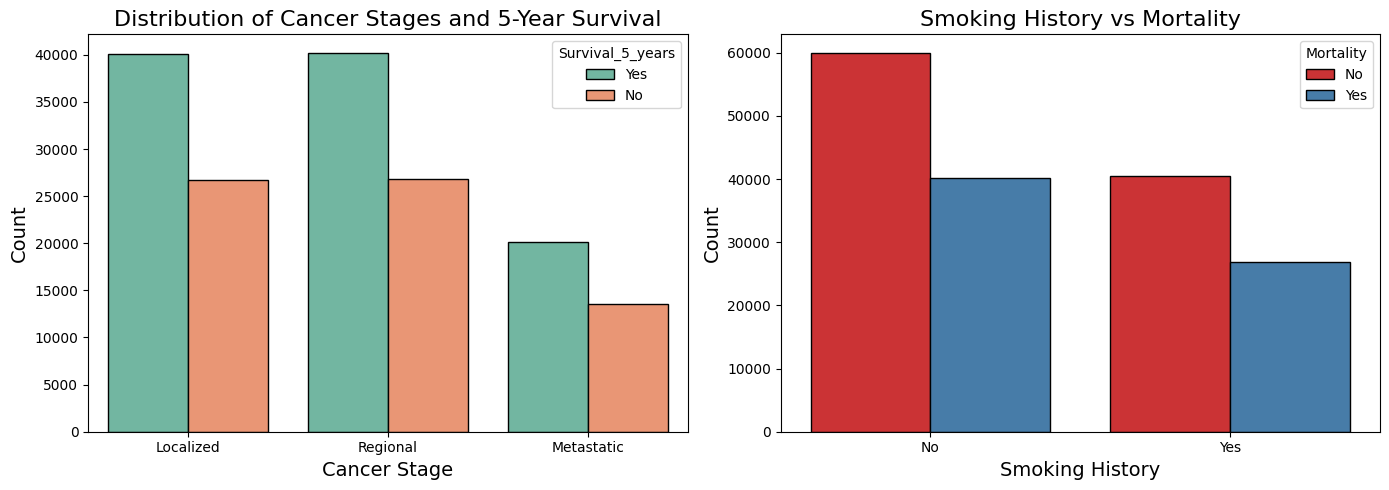

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Cancer_Stage', data=df, hue='Survival_5_years', palette='Set2', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of Cancer Stages and 5-Year Survival', fontsize=16)
axes[0].set_xlabel('Cancer Stage', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)

sns.countplot(x="Smoking_History", data=df, hue="Mortality", palette="Set1", edgecolor="black", ax=axes[1])
axes[1].set_title("Smoking History vs Mortality", fontsize=16)
axes[1].set_xlabel("Smoking History", fontsize=14)
axes[1].set_ylabel("Count", fontsize=14)

plt.tight_layout()
plt.show()

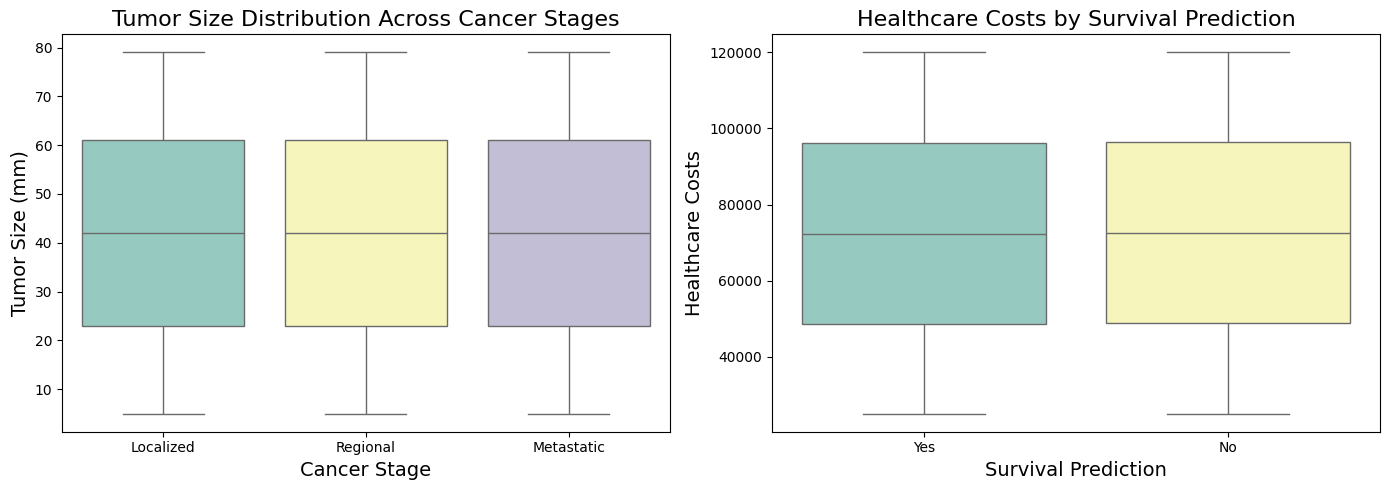

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Cancer_Stage', y='Tumor_Size_mm', data=df, palette='Set3', hue="Cancer_Stage", legend=False, ax=axes[0])
axes[0].set_title('Tumor Size Distribution Across Cancer Stages', fontsize=16)
axes[0].set_xlabel('Cancer Stage', fontsize=14)
axes[0].set_ylabel('Tumor Size (mm)', fontsize=14)

sns.boxplot(x='Survival_Prediction', y='Healthcare_Costs', data=df, palette='Set3', hue="Survival_Prediction", legend=False, ax=axes[1])
axes[1].set_title('Healthcare Costs by Survival Prediction', fontsize=16)
axes[1].set_xlabel('Survival Prediction', fontsize=14)
axes[1].set_ylabel('Healthcare Costs', fontsize=14)

plt.tight_layout()
plt.show()


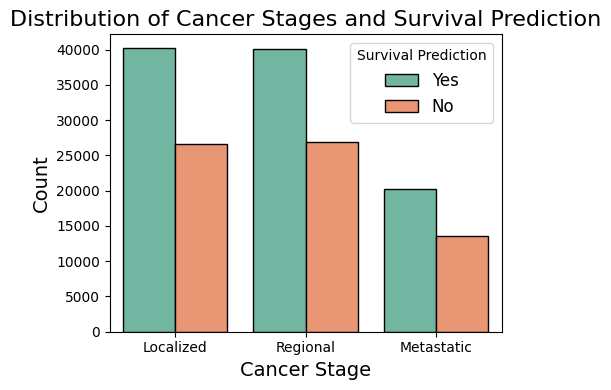

In [95]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Cancer_Stage', data=df, palette='Set2', hue='Survival_Prediction', edgecolor='black')
plt.title('Distribution of Cancer Stages and Survival Prediction', fontsize=16)
plt.xlabel('Cancer Stage', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Survival Prediction', fontsize=12)
plt.tight_layout()
plt.show()

## Data Processing

In [96]:
df = df.drop('Patient_ID', axis=1)

In [97]:
X = df.drop('Survival_Prediction', axis=1)
y = df['Survival_Prediction']

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [99]:
cat_cols = X_train.select_dtypes(include=['object']).columns

C:\Users\mkuma\AppData\Local\Temp\ipykernel_35252\137063067.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns


In [100]:
label_encoders = {}
mappings = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    mappings[col] = {label: code for label, code in zip(le.classes_, le.transform(le.classes_))}

In [101]:
for col in cat_cols:
    X_test[col] = label_encoders[col].transform(X_test[col])

In [138]:
X_cat = X_train.select_dtypes(include=['int64', 'float64'])
chi2_selector = SelectKBest(chi2, k="all")
chi2_selector.fit(X_cat, y_train)

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function chi...0026546187270>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",'all'


In [139]:
chi2_scores = pd.DataFrame({
        'Feature': X_cat.columns,
        'Chi2_Scores': chi2_selector.scores_
}).sort_values(by='Chi2_Scores', ascending=False).reset_index(drop=True)

In [104]:
top_features = chi2_scores.head(25)['Feature'].tolist()

X_train_filtered = X_train[top_features]
X_test_filtered = X_test[top_features]


In [105]:
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

In [106]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)


## Model Selection

In [107]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score

In [108]:
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Adaboost Classifier': AdaBoostClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier()
}

In [109]:
metrics = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': []
}

In [110]:
for model_name, model in classifiers.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"Model: {model_name}")
    print("-"  * 40)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 40)

    metrics['Model'].append(model_name)
    metrics['Accuracy'].append(accuracy)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1 Score'].append(f1)

Model: Logistic Regression
----------------------------------------
Accuracy: 0.5996
Precision: 0.5996
Recall: 1.0000
F1 Score: 0.7497
----------------------------------------
Model: Random Forest
----------------------------------------
Accuracy: 0.5606
Precision: 0.6006
Recall: 0.7980
F1 Score: 0.6854
----------------------------------------
Model: Gradient Boosting
----------------------------------------
Accuracy: 0.5996
Precision: 0.5997
Recall: 0.9988
F1 Score: 0.7495
----------------------------------------
Model: Adaboost Classifier
----------------------------------------
Accuracy: 0.5996
Precision: 0.5996
Recall: 1.0000
F1 Score: 0.7497
----------------------------------------
Model: Decision Tree
----------------------------------------
Accuracy: 0.5205
Precision: 0.6017
Recall: 0.5930
F1 Score: 0.5973
----------------------------------------
Model: GaussianNB
----------------------------------------
Accuracy: 0.5996
Precision: 0.5996
Recall: 1.0000
F1 Score: 0.7497
--------

In [111]:
metrics_df = pd.DataFrame(metrics).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

In [112]:
metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.599642,0.599642,1.000000,0.749720
1,Adaboost Classifier,0.599642,0.599642,1.000000,0.749720
2,GaussianNB,0.599642,0.599642,1.000000,0.749720
3,Gradient Boosting,0.599582,0.599749,0.998805,0.749468
4,GradientBoostingClassifier,0.599582,0.599749,0.998805,0.749468
5,Random Forest,0.560627,0.600569,0.798039,0.685364
6,KNeighborsClassifier,0.535313,0.598742,0.682348,0.637817
7,Decision Tree,0.520537,0.601677,0.592991,0.597302


In [113]:
gb = GradientBoostingClassifier()
params = {
    'n_estimators': randint(100, 200),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 5)
}

In [114]:
random_search = RandomizedSearchCV(estimator=gb, param_distributions=params, n_iter=5, cv=2, scoring='accuracy', verbose=2, n_jobs=-1)
random_search.fit(X_train_scaled, y_train)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': <scipy.stats....00265033182D0>, 'max_depth': <scipy.stats....0026507025E00>, 'n_estimators': <scipy.stats....0026503318050>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be u

In [115]:
best_params = random_search.best_params_
print("Best Hyperparameters for Gradient Boosting Classifier:", best_params)

Best Hyperparameters for Gradient Boosting Classifier: {'learning_rate': np.float64(0.03989134081316627), 'max_depth': 3, 'n_estimators': 189}


In [116]:
best_score = random_search.best_score_
print("Best Cross-Validation Accuracy:", best_score)

Best Cross-Validation Accuracy: 0.5995805875471009


In [117]:
best_gb_model = random_search.best_estimator_
y_pred_gb = best_gb_model.predict(X_test_scaled)

In [118]:
accuracy = accuracy_score(y_test, y_pred_gb)
precision = precision_score(y_test, y_pred_gb)
recall = recall_score(y_test, y_pred_gb)
f1 = f1_score(y_test, y_pred_gb)

In [122]:
print("Accuracy : ", accuracy, "Precision : ", precision, "Recall : ", recall, "F1 Score : ", f1)

Accuracy :  0.5995820895522388 Precision :  0.5996952676864244 Recall :  0.9992532855436081 F1 Score :  0.7495519044062733


In [124]:
sample_data = [X_train_scaled[0]]
sample_prediction = best_gb_model.predict(sample_data)
if sample_prediction[0] == 1:
    print("The model predicts that the patient will survive. ")

The model predicts that the patient will survive. 


In [127]:
y_proba = best_gb_model.predict_proba(X_test_scaled)[:, 1] if len(y.unique()) == 2 else None

In [128]:
roc_curve = roc_auc_score(y_test, y_proba)
print("ROC AUC Score: ", roc_curve)

ROC AUC Score:  0.498833272580663


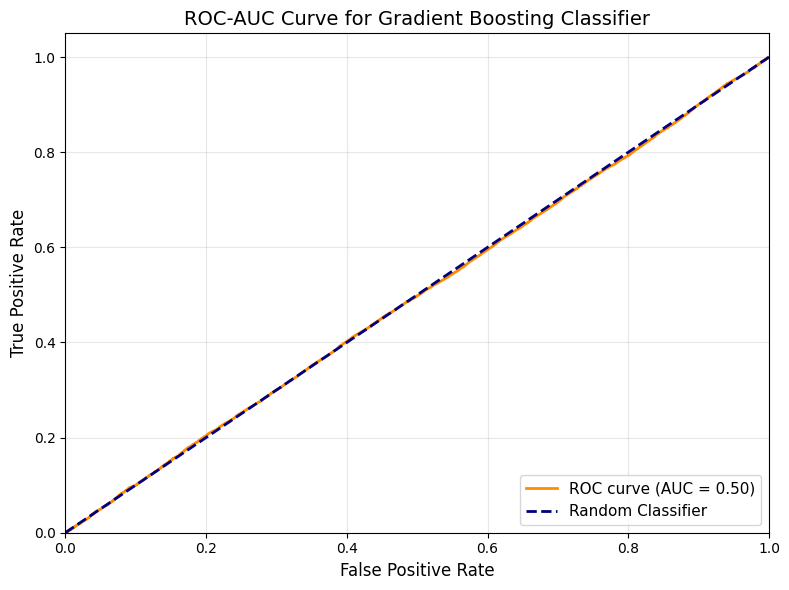

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve for Gradient Boosting Classifier', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()